<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
Final estimate of b and w: 0.4284489581739146 [0.48270238 0.75265969 0.46109174]


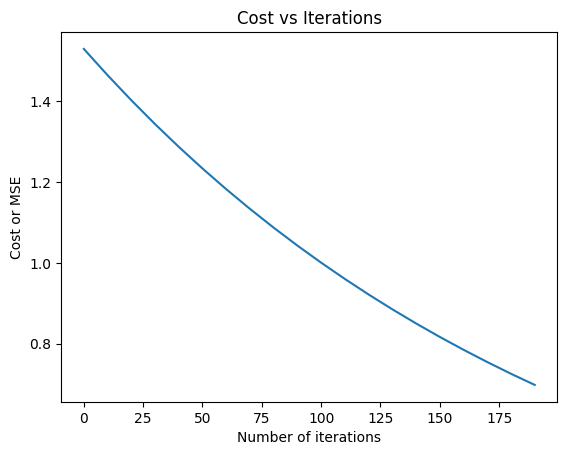

Final estimates of b and w: 0.4284489581739146 [0.48270238 0.75265969 0.46109174]
Final estimate of b and w: -4.072322631502196e-17 [ 0.75306591  0.53648155 -0.00433069]
Final estimate of b and w: 0.011664695556930216 [0.74315125 0.52779959 0.01171703]


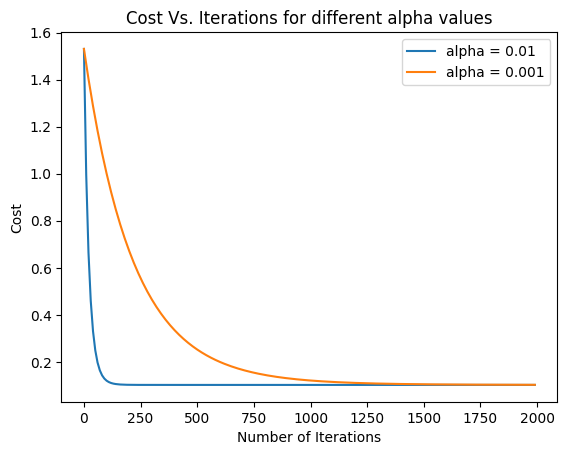

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

sales_df = pd.read_csv('Advertising.csv')
sales_df.head()

X = sales_df[['TV','newspaper','radio']]
Y = sales_df['sales']

# Standardize
X = np.array((X - X.mean()) / X.std())
Y = np.array((Y - Y.mean()) / Y.std())

# ================================
# Initialize bias and weights
# ================================
def initialize(dim):
    np.random.seed(42)
    random.seed(42)
    b = random.random()
    w = np.random.rand(dim)
    return b, w

# ================================
# Prediction
# ================================
def predict_Y(b, w, X):
    return b + np.dot(X, w)

# ================================
# Cost Function (MSE)
# ================================
def get_cost(Y, Y_hat):
    return np.mean((Y - Y_hat) ** 2)

# ================================
# Update Parameters
# ================================
def update_beta(X, Y, Y_hat, b, w, alpha):
    db = 2 * np.mean(Y_hat - Y)
    dw = 2 * np.dot((Y_hat - Y), X) / len(Y)
    b = b - alpha * db
    w = w - alpha * dw
    return b, w

# ================================
# Gradient Descent
# ================================
def run_gradient_descent(X, Y, alpha=0.01, num_iterations=100):
    b, w = initialize(X.shape[1])
    history = []

    for i in range(num_iterations):
        Y_hat = predict_Y(b, w, X)
        cost = get_cost(Y, Y_hat)
        b, w = update_beta(X, Y, Y_hat, b, w, alpha)

        if i % 10 == 0:
            history.append([i, cost])

    history_df = pd.DataFrame(history, columns=['iteration', 'cost'])
    print("Final estimate of b and w:", b, w)
    return history_df, b, w

# ================================
# Example Outputs
# ================================
b, w = initialize(3)
print("Bias:", b, "Weights:", w)

Y_hat = predict_Y(b, w, X)
print("\nFirst 10 Predicted Values:")
print(Y_hat[:10])

print("\nInitial Cost:")
print(get_cost(Y, Y_hat))

b, w = update_beta(X, Y, Y_hat, b, w, 0.01)
print("\nAfter first update - Bias:", b, "Weights:", w)

# ================================
# Run Gradient Descent
# ================================
gd_iterations_df, b, w = run_gradient_descent(X, Y, alpha=0.001, num_iterations=200)

print("\nGradient Descent Iterations:")
print(gd_iterations_df.head(10))

# Plot Cost vs Iterations
plt.plot(gd_iterations_df['iteration'], gd_iterations_df['cost'])
plt.xlabel("Number of iterations")
plt.ylabel("Cost or MSE")
plt.title("Cost vs Iterations")
plt.show()

print("Final estimates of b and w:", b, w)

# ================================
# Compare Learning Rates
# ================================
alpha_df_1, _, _ = run_gradient_descent(X, Y, alpha=0.01, num_iterations=2000)
alpha_df_2, _, _ = run_gradient_descent(X, Y, alpha=0.001, num_iterations=2000)

plt.plot(alpha_df_1['iteration'], alpha_df_1['cost'], label="alpha = 0.01")
plt.plot(alpha_df_2['iteration'], alpha_df_2['cost'], label="alpha = 0.001")

plt.legend()
plt.ylabel('Cost')
plt.xlabel('Number of Iterations')
plt.title('Cost Vs. Iterations for different alpha values')
plt.show()

In [4]:
print(sales_df)

     Unnamed: 0     TV  radio  newspaper  sales
0             1  230.1   37.8       69.2   22.1
1             2   44.5   39.3       45.1   10.4
2             3   17.2   45.9       69.3    9.3
3             4  151.5   41.3       58.5   18.5
4             5  180.8   10.8       58.4   12.9
..          ...    ...    ...        ...    ...
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4

[200 rows x 5 columns]


In [3]:
import ollama

response = ollama.chat(
    model="llama3",
    messages=[{"role": "user", "content": "fix this python code: def add(a b): return a+b"}]
)

print(response["message"]["content"])

ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
